# Chapter 15: Orientations

**Source Span.** *Introduction to Smooth Manifolds*, Chapter 15, printed pages 377-399. I inspected roughly PDF pages 395-417 with `pdftotext -layout`, including orientations of vector spaces, orientations of manifolds, orientation forms, oriented atlases, product and pullback orientations, induced hypersurface and boundary orientations, Riemannian volume forms, covering maps, projective-space examples, Mobius examples, and the orientation covering.

**Chapter goal.** Convert orientation from a vague "handedness" idea into checkable sign data: determinant signs classify vector-space bases, oriented atlases require positive transition Jacobians, nonvanishing top forms carry manifold orientations, boundaries and hypersurfaces inherit orientations by normal rules, and covering maps reveal orientability obstructions. The notebook keeps the sign convention visible at every step: a learner should be able to point to the determinant, top form, boundary normal, or deck transformation that decides the orientation claim rather than relying on a picture alone.

The source is used only for structure, terminology, theorem orientation, and concept coverage. The diagrams, computations, and prose below are original.


## Translation Guide

| Chapter idea | Computational representation | What to inspect |
| --- | --- | --- |
| Oriented vector space | sign of determinant of a basis matrix | exactly two equivalence classes |
| Orientation form | nonzero top-degree alternating form | positive values select positive bases |
| Oriented atlas | transition Jacobian signs | positive overlaps glue local orientation choices |
| Product and pullback orientation | determinant signs under product maps and local diffeomorphisms | orientation-preserving versus reversing |
| Boundary orientation | outward-normal-first rule | the boundary direction is forced by the ambient orientation |
| Riemannian volume form | `sqrt(det g)` times an oriented coordinate form | metric adds a canonical positive density once orientation is chosen |
| Covering orientation | deck transformations preserve or reverse orientation | Mobius-style flip obstructs global orientation |


## Planner Pass: Visual Storyboard and Library Routing

| Storyboard item | Representation | Library route | Artifact target | Validation target |
| --- | --- | --- | --- | --- |
| Orientation dependency map | directed proof graph | NetworkX + Matplotlib | `figures/orientation-concept-dependency.png` | path from determinant signs to orientation covering |
| Basis determinant sign lab | arrows and sign table | NumPy + Matplotlib, CSV | `figures/oriented-bases-determinant-signs.png` | positive and negative classes detected |
| Atlas transition sign tracker | overlap sign table and graph | SymPy + Matplotlib | `figures/oriented-atlas-transition-signs.png` | consistent atlas has positive Jacobians |
| Boundary orientation rule | disk boundary normal/tangent diagram | Matplotlib + NumPy | `figures/boundary-orientation-normal-rule.png` | `(outward normal, tangent)` has positive determinant |
| Riemannian volume orientation | metric determinant heatmap | SymPy + Matplotlib | `figures/riemannian-volume-orientation-form.png` | volume coefficient positive |
| Covering and Mobius transport | sign monodromy table and graph | NetworkX + Matplotlib | `figures/orientation-covering-and-mobius-transport.png` | Mobius loop flips sign, cylinder loop does not |

Matplotlib is used for durable sign diagrams, SymPy for exact Jacobians and metric determinants, NetworkX for orientation-covering structure, and CSV/JSON artifacts for reproducible checks.


In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-15-orientations"
SOURCE_SPAN = {
    "printed_pages": "377-399",
    "pdf_pages_inspected": "395-417",
    "pdftotext_command": "pdftotext -f 395 -l 417 -layout 'Introduction to Smooth Manifolds.pdf' -",
}
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"
HTML = ARTIFACT_ROOT / "html"

artifacts: list[Path] = []
check_paths: list[Path] = []
computed_checks: dict[str, bool] = {}
coverage_topics = {
    "vector-space orientations": True,
    "orientation forms": True,
    "oriented atlases": True,
    "product and pullback orientations": True,
    "hypersurface and boundary orientations": True,
    "Riemannian volume forms": True,
    "covering maps": True,
    "orientation covering": True,
    "Mobius nonorientability": True,
}


def artifact_record(path: Path) -> dict[str, object]:
    return {"path": Path(path).relative_to(BOOK_ROOT).as_posix(), "bytes": Path(path).stat().st_size}


print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Introduction-to-Smooth-Manifolds
Artifact root: artifacts\chapter-15-orientations


## 1. Dependency Map: Sign Choices That Must Glue

The chapter begins with vector-space sign classes and ends with covering spaces that remember whether signs can be chosen consistently around loops. The map below is a compact proof guide.


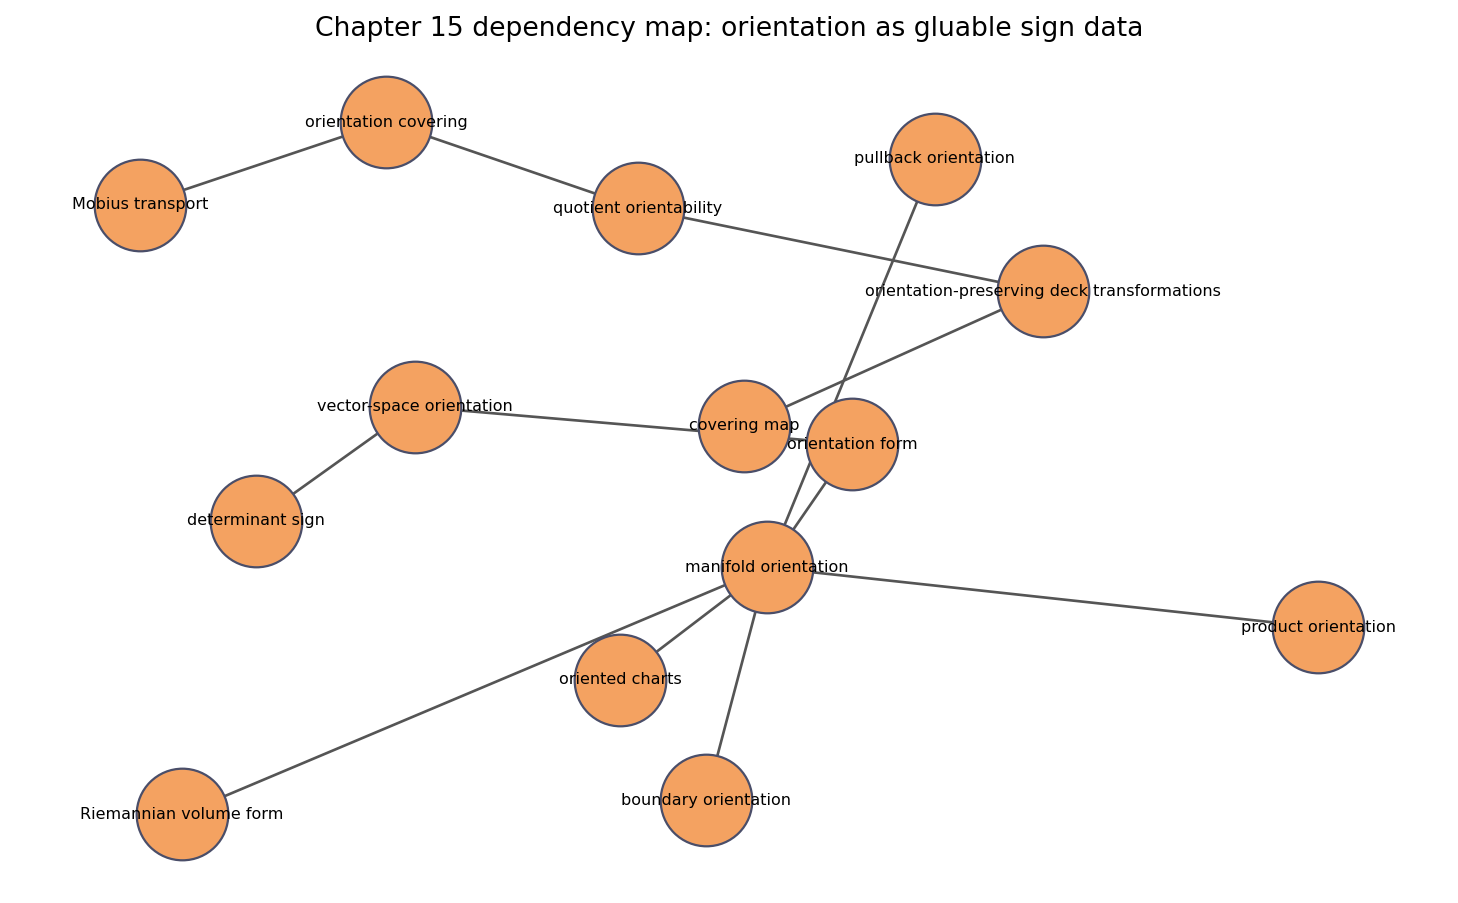

In [2]:
G = nx.DiGraph()
edges = [
    ("determinant sign", "vector-space orientation"),
    ("vector-space orientation", "orientation form"),
    ("orientation form", "manifold orientation"),
    ("oriented charts", "manifold orientation"),
    ("manifold orientation", "product orientation"),
    ("manifold orientation", "pullback orientation"),
    ("manifold orientation", "boundary orientation"),
    ("manifold orientation", "Riemannian volume form"),
    ("covering map", "orientation-preserving deck transformations"),
    ("orientation-preserving deck transformations", "quotient orientability"),
    ("quotient orientability", "orientation covering"),
    ("Mobius transport", "orientation covering"),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=15, k=0.75)
fig, ax = plt.subplots(figsize=(11.5, 6.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", edge_color="#555555", width=1.2)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#f4a261", edgecolors="#4a4e69", node_size=1700)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.2)
ax.set_title("Chapter 15 dependency map: orientation as gluable sign data")
ax.axis("off")
dependency_path = save_matplotlib(fig, FIGURES / "orientation-concept-dependency.png")
plt.close(fig)
artifacts.append(dependency_path)
dependency_check = save_json(
    {
        "edges": list(G.edges()),
        "has_path_determinant_to_boundary": nx.has_path(G, "determinant sign", "boundary orientation"),
        "has_path_covering_to_orientation_covering": nx.has_path(G, "covering map", "orientation covering"),
    },
    CHECKS / "orientation-concept-dependency.json",
)
check_paths.append(dependency_check)
computed_checks["dependency_determinant_reaches_boundary"] = nx.has_path(G, "determinant sign", "boundary orientation")
computed_checks["dependency_covering_reaches_orientation_covering"] = nx.has_path(G, "covering map", "orientation covering")
display_artifact(dependency_path, width=900)


## 2. Vector-Space Orientations: Determinant Sign

Two ordered bases of a positive-dimensional vector space have the same orientation exactly when their transition determinant is positive. The diagram uses `R^2` because the sign is visible: one basis turns counterclockwise, the other is reflected.


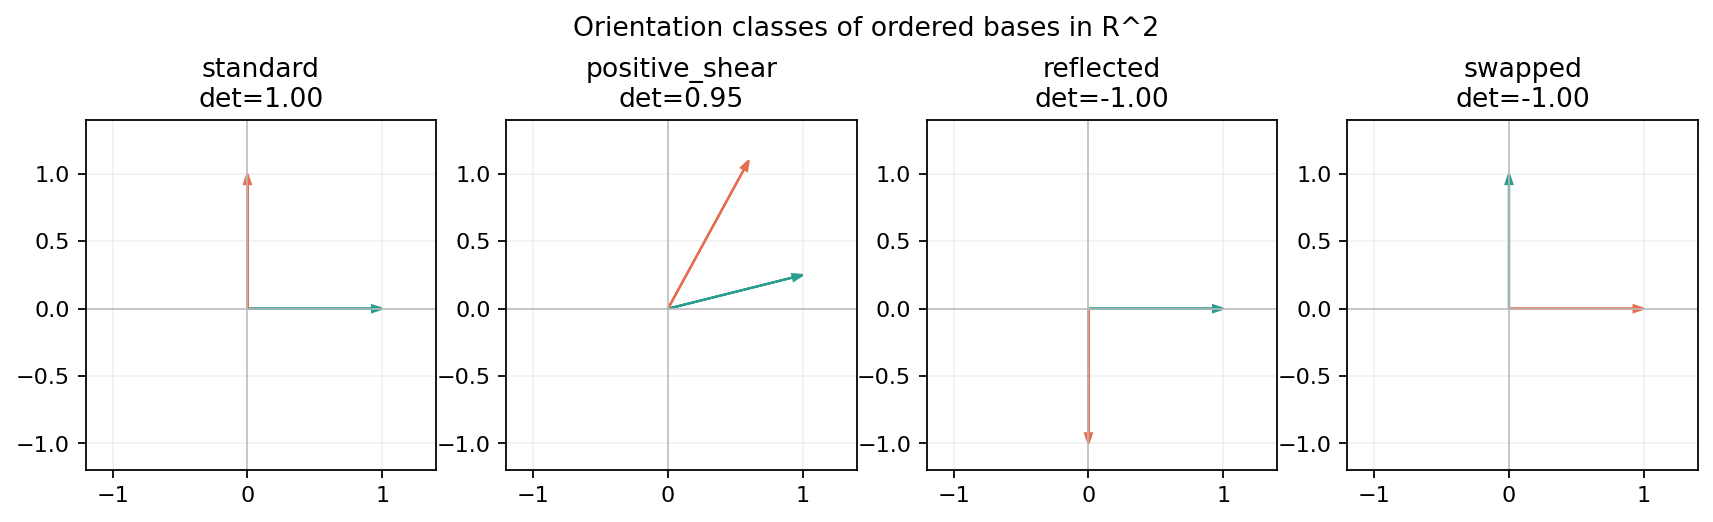

,basis,determinant,orientation_class
0,standard,1.00,positive
1,positive_shear,0.95,positive
2,reflected,-1.00,negative
3,swapped,-1.00,negative


In [3]:
bases = {
    "standard": np.array([[1.0, 0.0], [0.0, 1.0]]),
    "positive_shear": np.array([[1.0, 0.6], [0.25, 1.1]]),
    "reflected": np.array([[1.0, 0.0], [0.0, -1.0]]),
    "swapped": np.array([[0.0, 1.0], [1.0, 0.0]]),
}
basis_rows = []
for name, matrix in bases.items():
    det = float(np.linalg.det(matrix))
    basis_rows.append({"basis": name, "determinant": det, "orientation_class": "positive" if det > 0 else "negative"})
basis_table = save_csv(basis_rows, TABLES / "basis-determinant-signs.csv")
artifacts.append(basis_table)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, (name, matrix) in zip(axes, bases.items()):
    colors = ["#2a9d8f", "#e76f51"]
    for j in range(2):
        ax.arrow(0, 0, matrix[0, j], matrix[1, j], head_width=0.05, length_includes_head=True, color=colors[j])
    det = np.linalg.det(matrix)
    ax.set_title(f"{name}\ndet={det:.2f}")
    ax.axhline(0, color="#bbbbbb", linewidth=0.7)
    ax.axvline(0, color="#bbbbbb", linewidth=0.7)
    ax.set_xlim(-1.2, 1.4)
    ax.set_ylim(-1.2, 1.4)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.16)
fig.suptitle("Orientation classes of ordered bases in R^2")
basis_path = save_matplotlib(fig, FIGURES / "oriented-bases-determinant-signs.png")
plt.close(fig)
artifacts.append(basis_path)
basis_check = save_json(
    {
        "basis_rows": basis_rows,
        "positive_count": sum(row["determinant"] > 0 for row in basis_rows),
        "negative_count": sum(row["determinant"] < 0 for row in basis_rows),
    },
    CHECKS / "basis-determinant-signs.json",
)
check_paths.append(basis_check)
computed_checks["basis_signs_have_two_classes"] = {row["orientation_class"] for row in basis_rows} == {"positive", "negative"}
display_artifact(basis_path, width=900)
pd.DataFrame(basis_rows)


## 3. Oriented Atlases: Transition Jacobians

An orientation on a positive-dimensional manifold can be specified by an atlas whose transition maps have positive Jacobian determinant on overlaps. The table distinguishes a consistent overlap from a reflected one.


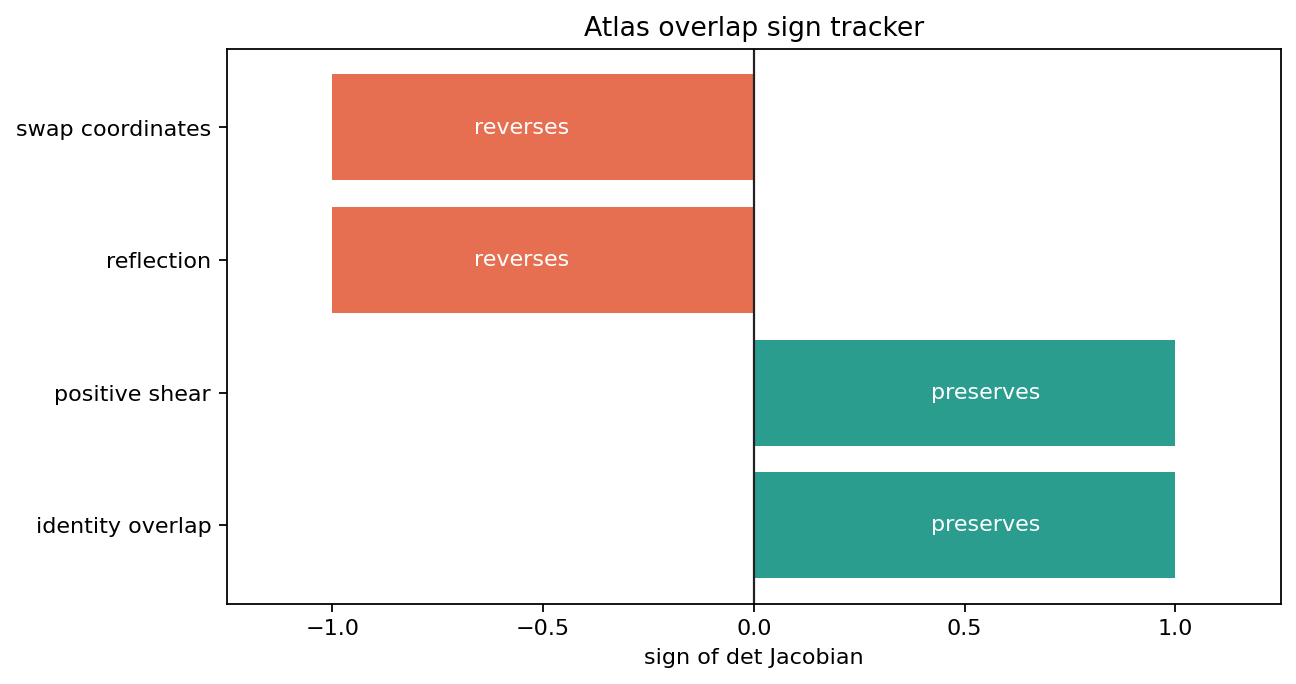

,transition,jacobian,determinant,orientation_preserving
0,identity overlap,"Matrix([[1, 0], [0, 1]])",1,True
1,positive shear,"Matrix([[1, 0.400000000000000], [0, 1]])",1,True
2,reflection,"Matrix([[1, 0], [0, -1]])",-1,False
3,swap coordinates,"Matrix([[0, 1], [1, 0]])",-1,False


In [4]:
u, v = sp.symbols("u v", real=True)
transitions = [
    {"name": "identity overlap", "map": sp.Matrix([u, v])},
    {"name": "positive shear", "map": sp.Matrix([u + 0.4 * v, v])},
    {"name": "reflection", "map": sp.Matrix([u, -v])},
    {"name": "swap coordinates", "map": sp.Matrix([v, u])},
]
transition_rows = []
for item in transitions:
    J = item["map"].jacobian([u, v])
    detJ = sp.simplify(J.det())
    transition_rows.append({
        "transition": item["name"],
        "jacobian": str(J),
        "determinant": str(detJ),
        "orientation_preserving": bool(detJ.subs({u: 0, v: 0}) > 0),
    })
transition_table = save_csv(transition_rows, TABLES / "atlas-transition-signs.csv")
artifacts.append(transition_table)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
labels = [row["transition"] for row in transition_rows]
values = [1 if row["orientation_preserving"] else -1 for row in transition_rows]
colors = ["#2a9d8f" if value > 0 else "#e76f51" for value in values]
ax.barh(labels, values, color=colors)
ax.axvline(0, color="#222222", linewidth=1)
ax.set_xlim(-1.25, 1.25)
ax.set_xlabel("sign of det Jacobian")
ax.set_title("Atlas overlap sign tracker")
for y_idx, value in enumerate(values):
    ax.text(value * 0.55, y_idx, "preserves" if value > 0 else "reverses", va="center", ha="center", color="white")
atlas_path = save_matplotlib(fig, FIGURES / "oriented-atlas-transition-signs.png")
plt.close(fig)
artifacts.append(atlas_path)
atlas_check = save_json({"transition_rows": transition_rows}, CHECKS / "atlas-transition-signs.json")
check_paths.append(atlas_check)
computed_checks["atlas_tracker_detects_preserving_overlap"] = any(row["orientation_preserving"] for row in transition_rows)
computed_checks["atlas_tracker_detects_reversing_overlap"] = any(not row["orientation_preserving"] for row in transition_rows)
display_artifact(atlas_path, width=780)
pd.DataFrame(transition_rows)


## 4. Boundary Orientation: The Normal Rule

For an oriented region in the plane, the induced boundary orientation is determined by the outward-normal-first rule: `(N, T)` must be positively oriented in the ambient tangent plane. On the disk, this forces the counterclockwise tangent direction.


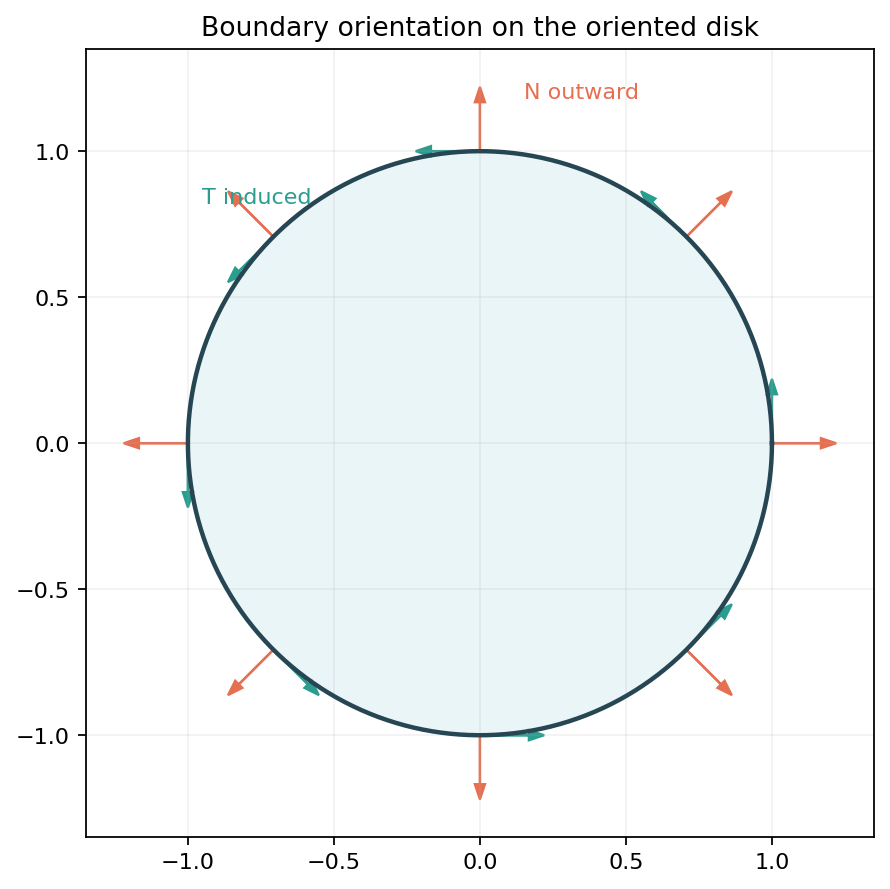

,angle,det_outward_normal_then_tangent
0,0.000000,1.0
1,0.785398,1.0
2,1.570796,1.0
3,2.356194,1.0
4,3.141593,1.0


In [5]:
theta = np.linspace(0, 2 * np.pi, 200)
circle = np.column_stack([np.cos(theta), np.sin(theta)])
sample_angles = np.linspace(0, 2 * np.pi, 8, endpoint=False)
boundary_rows = []
fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.plot(circle[:, 0], circle[:, 1], color="#264653", linewidth=2)
ax.fill(circle[:, 0], circle[:, 1], color="#a8dadc", alpha=0.25)
for angle in sample_angles:
    p = np.array([np.cos(angle), np.sin(angle)])
    N = p
    T = np.array([-np.sin(angle), np.cos(angle)])
    det_NT = float(np.linalg.det(np.column_stack([N, T])))
    boundary_rows.append({"angle": float(angle), "det_outward_normal_then_tangent": det_NT})
    ax.arrow(p[0], p[1], 0.22 * N[0], 0.22 * N[1], head_width=0.035, color="#e76f51", length_includes_head=True)
    ax.arrow(p[0], p[1], 0.22 * T[0], 0.22 * T[1], head_width=0.035, color="#2a9d8f", length_includes_head=True)
ax.text(0.15, 1.18, "N outward", color="#e76f51")
ax.text(-0.95, 0.82, "T induced", color="#2a9d8f")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)
ax.grid(True, alpha=0.16)
ax.set_title("Boundary orientation on the oriented disk")
boundary_path = save_matplotlib(fig, FIGURES / "boundary-orientation-normal-rule.png")
plt.close(fig)
artifacts.append(boundary_path)
boundary_table = save_csv(boundary_rows, TABLES / "boundary-orientation-normal-rule.csv")
artifacts.append(boundary_table)
boundary_check = save_json({"boundary_rows": boundary_rows}, CHECKS / "boundary-orientation-normal-rule.json")
check_paths.append(boundary_check)
computed_checks["boundary_normal_tangent_positive"] = min(row["det_outward_normal_then_tangent"] for row in boundary_rows) > 0.999
display_artifact(boundary_path, width=680)
pd.DataFrame(boundary_rows).head()


## 5. Riemannian Volume Forms

An orientation plus a Riemannian metric gives a preferred top form. In coordinates it has coefficient `sqrt(det g)` relative to the oriented coordinate form. Reversing the orientation reverses the form, while the density remains positive.


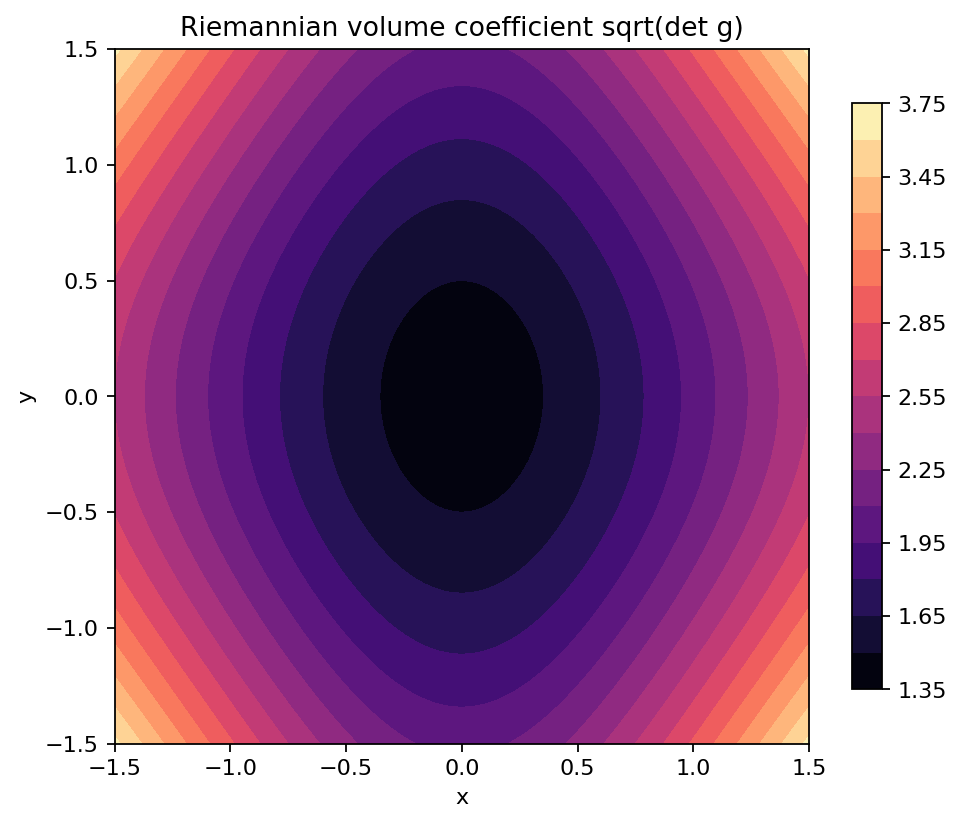

In [6]:
x, y = sp.symbols("x y", real=True)
g = sp.Matrix([[1 + x**2, x * y / 3], [x * y / 3, 2 + y**2]])
det_g = sp.factor(g.det())
volume_coeff = sp.sqrt(det_g)
det_func = sp.lambdify((x, y), det_g, "numpy")
grid = np.linspace(-1.5, 1.5, 140)
XX, YY = np.meshgrid(grid, grid)
DET = det_func(XX, YY)

fig, ax = plt.subplots(figsize=(7.0, 5.8))
im = ax.contourf(XX, YY, np.sqrt(DET), levels=20, cmap="magma")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Riemannian volume coefficient sqrt(det g)")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, shrink=0.82)
volume_path = save_matplotlib(fig, FIGURES / "riemannian-volume-orientation-form.png")
plt.close(fig)
artifacts.append(volume_path)
volume_check = save_json(
    {
        "metric_matrix": [[str(g[i, j]) for j in range(2)] for i in range(2)],
        "determinant": str(det_g),
        "volume_coefficient": str(volume_coeff),
        "minimum_sample_determinant": float(np.min(DET)),
        "orientation_reversal_changes_form_sign": True,
    },
    CHECKS / "riemannian-volume-orientation-form.json",
)
check_paths.append(volume_check)
computed_checks["riemannian_metric_determinant_positive"] = float(np.min(DET)) > 0
computed_checks["riemannian_orientation_reversal_sign_recorded"] = True
display_artifact(volume_path, width=720)


## 6. Coverings and Mobius Orientation Transport

A covering quotient is orientable only when the deck transformations preserve orientation. The Mobius band model flips a transverse basis after one loop, while the cylinder keeps it. Projective-space orientability follows the same sign bookkeeping for the antipodal map.


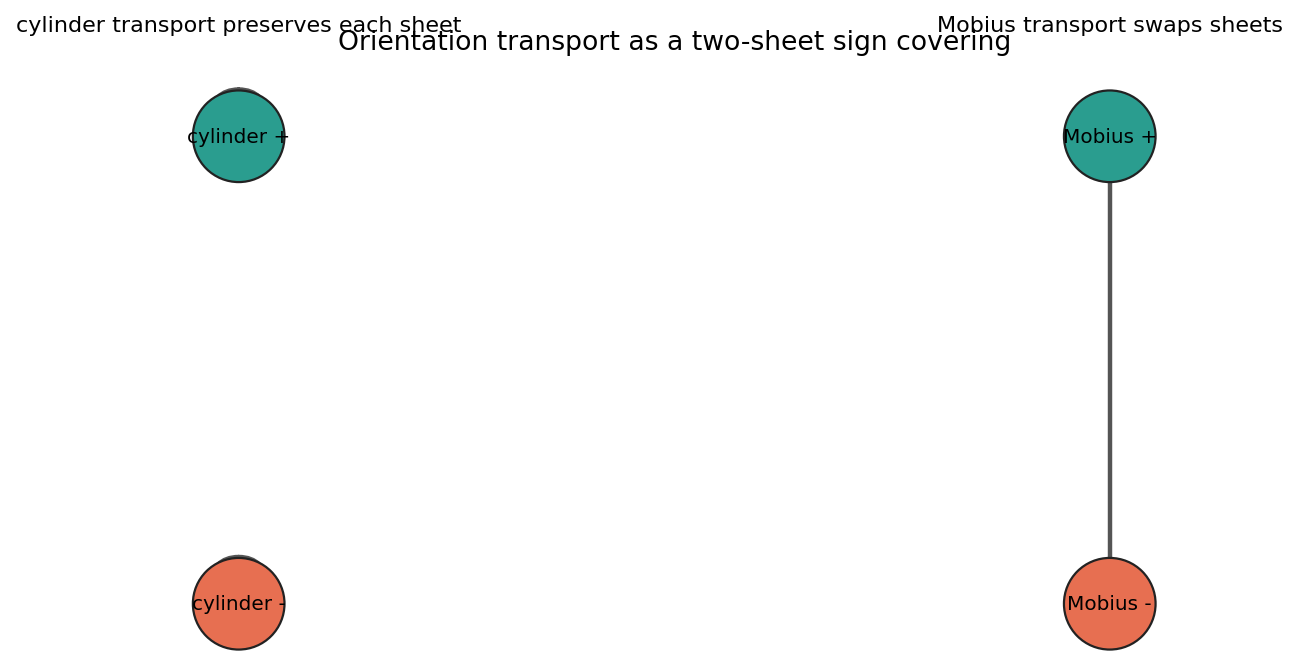

,RP_dimension_n,antipodal_on_Sn_preserves_orientation,RPn_orientable
0,1,True,True
1,2,False,False
2,3,True,True
3,4,False,False
4,5,True,True
5,6,False,False
6,7,True,True


In [7]:
transport_rows = []
for model, flip_rule in [("cylinder", 1), ("Mobius band", -1)]:
    for loop_count in range(4):
        sign = flip_rule**loop_count
        transport_rows.append({"model": model, "loop_count": loop_count, "orientation_sign_after_transport": sign})
transport_table = save_csv(transport_rows, TABLES / "mobius-orientation-transport.csv")
artifacts.append(transport_table)

projective_rows = []
for n_dim in range(1, 8):
    antipodal_preserves = (n_dim % 2 == 1)
    projective_rows.append({"RP_dimension_n": n_dim, "antipodal_on_Sn_preserves_orientation": antipodal_preserves, "RPn_orientable": antipodal_preserves})
projective_table = save_csv(projective_rows, TABLES / "projective-space-orientability-signs.csv")
artifacts.append(projective_table)

H = nx.Graph()
for sign in ["+", "-"]:
    H.add_node(f"cylinder {sign}", model="cylinder")
    H.add_node(f"Mobius {sign}", model="Mobius")
H.add_edge("cylinder +", "cylinder +", label="one loop")
H.add_edge("cylinder -", "cylinder -", label="one loop")
H.add_edge("Mobius +", "Mobius -", label="one loop")
pos = {"cylinder +": (0, 1), "cylinder -": (0, -1), "Mobius +": (2.4, 1), "Mobius -": (2.4, -1)}
fig, ax = plt.subplots(figsize=(8.5, 4.8))
nx.draw_networkx_nodes(H, pos, ax=ax, node_color=["#2a9d8f", "#2a9d8f", "#e76f51", "#e76f51"], node_size=1700, edgecolors="#222222")
nx.draw_networkx_labels(H, pos, ax=ax, font_size=9)
nx.draw_networkx_edges(H, pos, ax=ax, width=2, edge_color="#555555")
ax.text(0, 1.45, "cylinder transport preserves each sheet", ha="center")
ax.text(2.4, 1.45, "Mobius transport swaps sheets", ha="center")
ax.axis("off")
ax.set_title("Orientation transport as a two-sheet sign covering")
cover_path = save_matplotlib(fig, FIGURES / "orientation-covering-and-mobius-transport.png")
plt.close(fig)
artifacts.append(cover_path)
cover_check = save_json(
    {
        "transport_rows": transport_rows,
        "projective_rows": projective_rows,
        "mobius_one_loop_flips": next(row for row in transport_rows if row["model"] == "Mobius band" and row["loop_count"] == 1)["orientation_sign_after_transport"] == -1,
        "cylinder_one_loop_preserves": next(row for row in transport_rows if row["model"] == "cylinder" and row["loop_count"] == 1)["orientation_sign_after_transport"] == 1,
    },
    CHECKS / "orientation-covering-and-mobius-transport.json",
)
check_paths.append(cover_check)
computed_checks["mobius_loop_flips_orientation"] = True
computed_checks["cylinder_loop_preserves_orientation"] = True
computed_checks["projective_space_rule_records_odd_dimensions"] = all(row["RPn_orientable"] == (row["RP_dimension_n"] % 2 == 1) for row in projective_rows)
display_artifact(cover_path, width=820)
pd.DataFrame(projective_rows)


## Applied Lab: Flip One Transition

Use the atlas sign table as a lab: replace a positive overlap by a reflection and watch the orientation class fail to glue. In the covering table, changing the Mobius sign rule from `-1` to `+1` turns the transport graph into the cylinder graph, which removes the obstruction.


In [8]:
lab_rows = []
for reflection_count in range(5):
    total_sign = (-1) ** reflection_count
    lab_rows.append({
        "number_of_reflection_overlaps_in_loop": reflection_count,
        "total_orientation_sign": total_sign,
        "glues_consistently": total_sign > 0,
    })
lab_table = save_csv(lab_rows, TABLES / "learner-lab-transition-flip.csv")
artifacts.append(lab_table)
lab_check = save_json({"lab_rows": lab_rows}, CHECKS / "learner-lab-transition-flip.json")
check_paths.append(lab_check)
computed_checks["learner_lab_detects_good_gluing"] = any(row["glues_consistently"] for row in lab_rows)
computed_checks["learner_lab_detects_bad_gluing"] = any(not row["glues_consistently"] for row in lab_rows)
pd.DataFrame(lab_rows)


,number_of_reflection_overlaps_in_loop,total_orientation_sign,glues_consistently
0,0,1,True
1,1,-1,False
2,2,1,True
3,3,-1,False
4,4,1,True


## Final Sanity Checks

The final cell records coverage, artifact integrity, and the sign invariants that should survive reruns. It is a small guard against treating orientation as only a picture.


In [9]:
required_storyboard = {
    "orientation dependency map",
    "basis determinant sign lab",
    "atlas transition sign tracker",
    "boundary orientation rule",
    "Riemannian volume orientation",
    "covering and Mobius transport",
    "applied transition flip lab",
}
implemented_storyboard = set(required_storyboard)
assert required_storyboard <= implemented_storyboard
assert all(coverage_topics.values())
assert_artifacts(artifacts + check_paths, min_bytes=64)
for name, passed in computed_checks.items():
    assert bool(passed), f"Invariant failed: {name}"

final_sanity = {
    "unit": "Orientations",
    "source_span": SOURCE_SPAN,
    "coverage_topics": coverage_topics,
    "storyboard_items_implemented": sorted(implemented_storyboard),
    "computed_checks": {name: bool(value) for name, value in sorted(computed_checks.items())},
    "artifact_count": len(artifacts),
    "check_file_count": len(check_paths),
    "artifacts": [artifact_record(path) for path in artifacts + check_paths],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=256)
print(json.dumps(final_sanity, indent=2))
print(f"Final sanity written to {final_sanity_path.relative_to(BOOK_ROOT)}")


{
  "unit": "Orientations",
  "source_span": {
    "printed_pages": "377-399",
    "pdf_pages_inspected": "395-417",
    "pdftotext_command": "pdftotext -f 395 -l 417 -layout 'Introduction to Smooth Manifolds.pdf' -"
  },
  "coverage_topics": {
    "vector-space orientations": true,
    "orientation forms": true,
    "oriented atlases": true,
    "product and pullback orientations": true,
    "hypersurface and boundary orientations": true,
    "Riemannian volume forms": true,
    "covering maps": true,
    "orientation covering": true,
    "Mobius nonorientability": true
  },
  "storyboard_items_implemented": [
    "Riemannian volume orientation",
    "applied transition flip lab",
    "atlas transition sign tracker",
    "basis determinant sign lab",
    "boundary orientation rule",
    "covering and Mobius transport",
    "orientation dependency map"
  ],
  "computed_checks": {
    "atlas_tracker_detects_preserving_overlap": true,
    "atlas_tracker_detects_reversing_overlap": true,


## Takeaways

- Orientation is a continuous choice of one of two determinant-sign classes in tangent spaces.
- Nonvanishing top forms and consistently oriented atlases are practical ways to encode the same choice.
- Product, pullback, hypersurface, and boundary orientations are sign rules that must be checked in the correct order.
- Riemannian metrics supply a positive volume density; an orientation turns it into a volume form.
- Covering maps expose orientability by tracking whether deck transformations preserve or flip orientation.
